<a href="https://colab.research.google.com/github/irungus/Applied-Machine-Learning/blob/main/Predictive_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
url = "https://raw.githubusercontent.com/NUELBUNDI/Machine-Learning-Data-Set/refs/heads/main/Car%20Upload%20data.csv"

In [ ]:
df = pd.read_csv(url)

In [ ]:
df.head()

,id,name,model_name,price,price_currency,body_type,source,location,drive,mileage,...,highway_consumption,lane_assist,reverse_camera,adaptive_cruise_control,standard_cruise_control,antilock_braking_system,automatic_brake_hold_system,tyre_pressure_monitoring_system,number_of_airbags,gps_tracker
0,7593,Nissan March,March,829999,KES,Hatchback,Kenyan Used,Nairobi,2WD,97736,...,20.0,False,True,False,False,True,False,False,6.0,True
1,7592,Toyota Landcruiser 200 series (4.6L V8),Landcruiser 200 series,5499999,KES,SUV,Kenyan Used,Nairobi,4WD,94000,...,8.0,False,True,False,False,True,False,False,9.0,True
2,7591,Subaru Levorg,Levorg,1667499,KES,Station Wagon,Kenyan Used,Nairobi,AWD,99459,...,12.0,True,True,False,False,True,False,False,6.0,True
3,7590,Volkswagen Golf Variant 1.4,Golf Variant,1749999,KES,Estate,Kenyan Used,Nairobi,2WD,174000,...,20.0,True,True,True,False,True,False,False,6.0,True
4,7589,Mitsubishi Galant,Galant,489999,KES,Saloon,Kenyan Used,Nairobi,2WD,191833,...,12.0,False,False,False,False,True,False,False,6.0,True


In [ ]:
df.columns

Index(['id', 'name', 'model_name', 'price', 'price_currency', 'body_type',
       'source', 'location', 'drive', 'mileage', 'mileage_unit', 'color',
       'year_of_manufacture', 'annual_insurance', 'torque', 'cylinders',
       'fuel_type', 'aspiration', 'engine_size', 'transmission', 'horse_power',
       'seat_material', 'number_of_seats', 'heated_seats', 'air_conditioning',
       'trimming', 'infotainment_system', 'phone_connectivity',
       'auto_start_and_stop', 'keyless_entry_and_push_button_start',
       'steering_mounted_paddle_shifts', 'urban_consumption',
       'fuel_tank_capacity', 'highway_consumption', 'lane_assist',
       'reverse_camera', 'adaptive_cruise_control', 'standard_cruise_control',
       'antilock_braking_system', 'automatic_brake_hold_system',
       'tyre_pressure_monitoring_system', 'number_of_airbags', 'gps_tracker'],
      dtype='object')

Understanding missing numbers <br>
There are three categories <br>
*  Missing completely at random (MCAR) - Not related to any variable - Use all the techniques learnt on handling missing values
*  Missing at random (MAR). - Related to other variables in the data
*  Missing not at random (MNAR)

1. Deletion MCAR
2. Imputation


* Use Measure of Central tendancies/ simple estimated
* Predictive imputation
* Multiple imputation










In [ ]:
df['mileage_unit'].unique()

array(['KM', 'Miles'], dtype=object)

In [ ]:
del df['id']
del df['mileage_unit']

<Axes: >

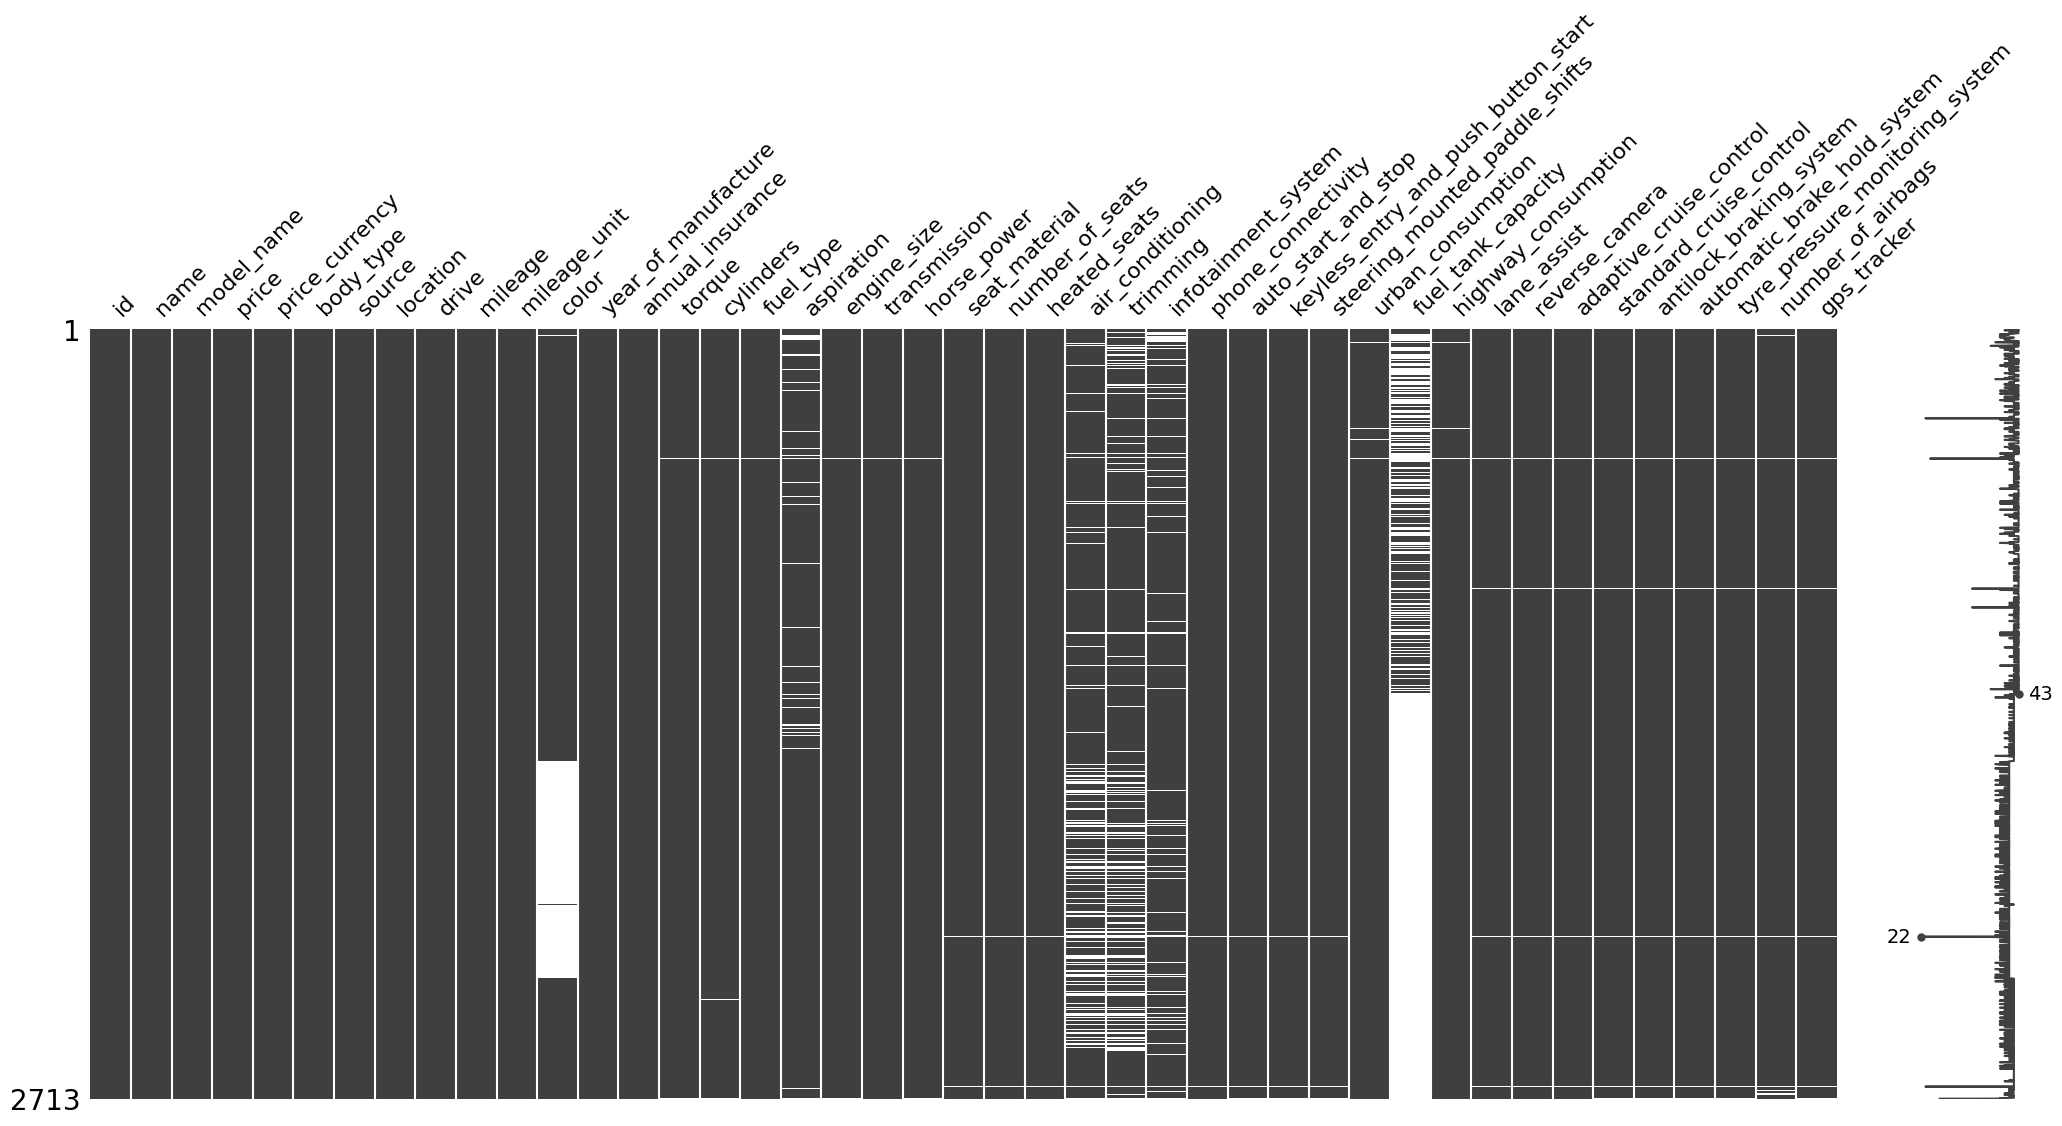

In [ ]:
#check missng
import missingno as msno
msno.matrix(df)

In [ ]:
# Create pipeline to do cleaning
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

cols_to_use_predictive = ['highway_consumption', 'urban_consumption']
col_to_not_available = ['air_conditioning', 'trimming', 'information_system']
col_to_iterative = ['number_of_airbags']
combined_features = cols_to_use_predictive + col_to_not_available + col_to_iterative
categorical_cols_feature =[col fo col in df.select_dtypes(include=['object','string','bool']).colums if col not in combined_features]
numerical_cols = df.select_dtypes(include=['int','float']).columns.tolist

custom_1_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant')),
])
custom_2_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=3)),
])
custom_3_pipeline = Pipeline(steps=[
    ('imputer', IterativeImputer()),
])
numerical_cols = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
])
categorical_col = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

#combine

preprocessor = ColumnTransformer(
        ('custom_1', custom_1_pipeline, col_to_not_available),
        ('custom_2', custom_2_pipeline, cols_to_use_predictive),
        ('custom_3', custom_3_pipeline, col_to_iterative),
        ('num', numerical_pipeline, numerical_cols),
        ('custom_4', categorical_col, categorical_cols_feature)
)

# final
cleaning_pipelined = Pipeline(steps=[('preprocessor', preprocessor)])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (<ipython-input-22-2163d6cb34c5>, line 12)

In [ ]:
df.select_dtypes(include='float')

,annual_insurance,torque,cylinders,engine_size,horse_power,number_of_seats,urban_consumption,fuel_tank_capacity,highway_consumption,number_of_airbags
0,34000.0,105.0,4.0,1200.0,78.0,5.0,18.0,41.0,20.0,6.0
1,220000.0,450.0,8.0,4600.0,314.0,7.0,6.0,93.0,8.0,9.0
2,66700.0,400.0,4.0,2000.0,300.0,5.0,10.0,60.0,12.0,6.0
3,840000.0,250.0,4.0,1400.0,150.0,5.0,18.0,50.0,20.0,6.0
4,20000.0,195.0,4.0,2000.0,155.0,5.0,10.0,60.0,12.0,6.0
...,...,...,...,...,...,...,...,...,...,...
2708,81000.0,127.0,4.0,1500.0,100.0,5.0,7.4,NaN,9.6,8.0
2709,42750.0,160.0,4.0,1600.0,120.0,5.0,8.4,NaN,5.4,7.0
2710,96750.0,420.0,4.0,2200.0,173.0,5.0,11.6,NaN,15.1,NaN
2711,111000.0,NaN,NaN,NaN,NaN,3.0,9.0,NaN,12.0,2.0
